# Exploratory Data Analysis (EDA) — Olist Late Deliveries

In this notebook, we explore the `orders_master` table to understand the drivers of **late deliveries**.
This analysis will inform our feature engineering (Phase 5) and business insights report (Phase 8).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# Connect to DuckDB
con = duckdb.connect('../data/olist.duckdb')

print("Connected to DuckDB successfully!")

Connected to DuckDB successfully!


## 1. The Target Variable: Late Deliveries
Let's establish the baseline class imbalance. We only look at delivered orders.

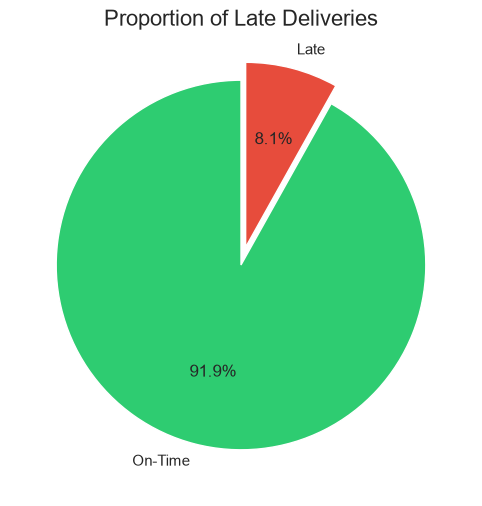

In [2]:
query_target = """
SELECT 
    CASE WHEN is_late = 1 THEN 'Late' ELSE 'On-Time' END AS delivery_status,
    COUNT(*) as num_orders
FROM orders_master 
WHERE is_delivered = 1
GROUP BY is_late
"""
df_target = con.execute(query_target).df()

plt.figure(figsize=(6,6))
plt.pie(df_target['num_orders'], labels=df_target['delivery_status'], autopct='%1.1f%%', 
        colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
plt.title('Proportion of Late Deliveries')
plt.show()

## 2. Geographic Logistics (State-by-State)
Does shipping to certain states increase the risk of a late delivery?

C:\Users\Dell\AppData\Local\Temp\ipykernel_24184\4278658664.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_state, x='customer_state', y='late_rate_pct', palette='rocket')


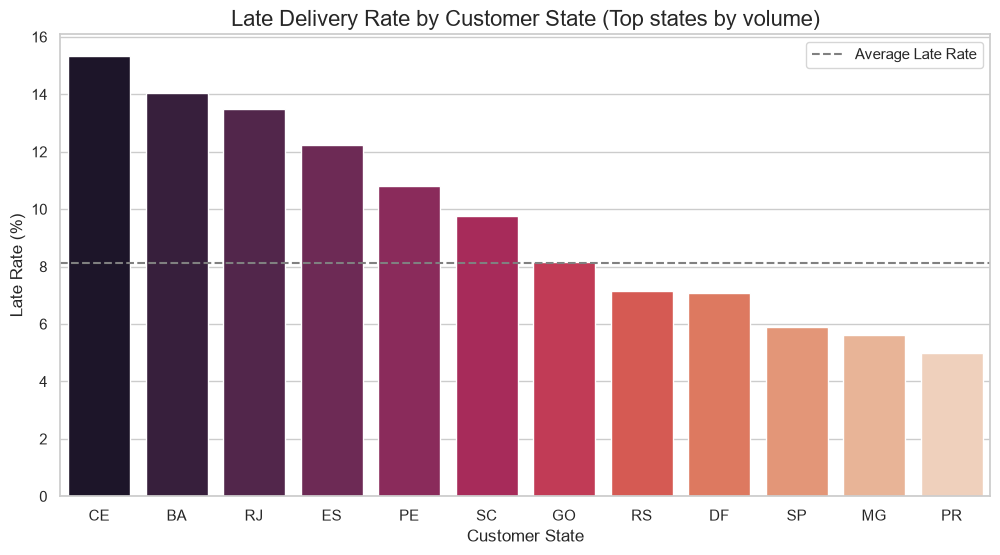

In [3]:
query_state = """
SELECT 
    customer_state,
    COUNT(*) as total_orders,
    AVG(CAST(is_late AS DOUBLE)) * 100 as late_rate_pct
FROM orders_master
WHERE is_delivered = 1
GROUP BY customer_state
HAVING total_orders > 1000
ORDER BY late_rate_pct DESC
"""
df_state = con.execute(query_state).df()

plt.figure(figsize=(12,6))
sns.barplot(data=df_state, x='customer_state', y='late_rate_pct', palette='rocket')
plt.title('Late Delivery Rate by Customer State (Top states by volume)')
plt.ylabel('Late Rate (%)')
plt.xlabel('Customer State')
plt.axhline(df_target[df_target['delivery_status']=='Late']['num_orders'].iloc[0] / df_target['num_orders'].sum() * 100, 
            color='gray', linestyle='--', label='Average Late Rate')
plt.legend()
plt.show()

## 3. Freight vs. Price Ratio (Economic Impact)
Are items where freight costs more than the item itself harder to ship on time?

C:\Users\Dell\AppData\Local\Temp\ipykernel_24184\1132593814.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_freight, x='delivery_status', y='freight_to_price_ratio', palette=['#2ecc71', '#e74c3c'])


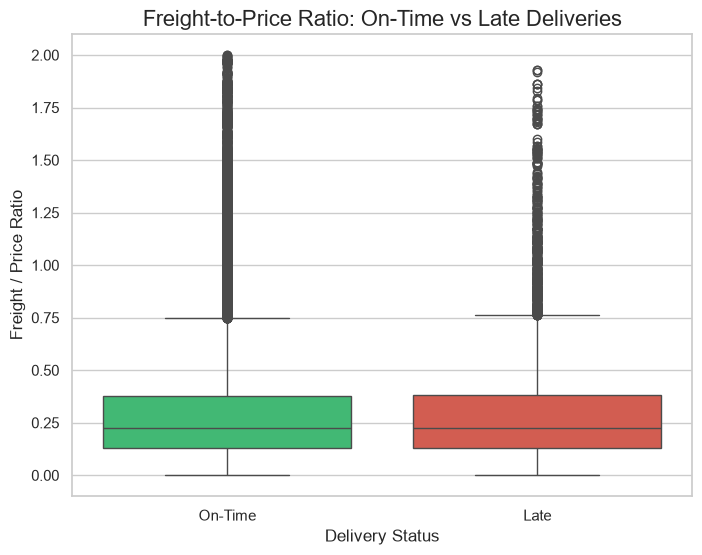

In [4]:
query_freight = """
SELECT 
    CASE WHEN is_late = 1 THEN 'Late' ELSE 'On-Time' END AS delivery_status,
    freight_to_price_ratio
FROM orders_master
WHERE is_delivered = 1 
  AND freight_to_price_ratio < 2.0 -- exclude extreme outliers for plotting
"""
df_freight = con.execute(query_freight).df()

plt.figure(figsize=(8,6))
sns.boxplot(data=df_freight, x='delivery_status', y='freight_to_price_ratio', palette=['#2ecc71', '#e74c3c'])
plt.title('Freight-to-Price Ratio: On-Time vs Late Deliveries')
plt.ylabel('Freight / Price Ratio')
plt.xlabel('Delivery Status')
plt.show()

## 4. Customer Satisfaction Impact
What is the exact impact of a late delivery on customer reviews?

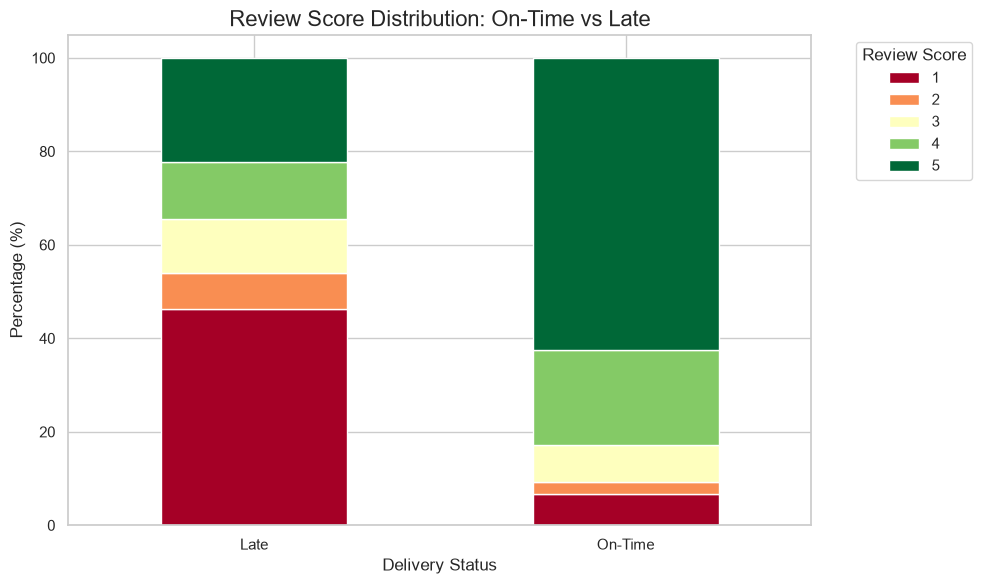

In [5]:
query_reviews = """
SELECT 
    CASE WHEN is_late = 1 THEN 'Late' ELSE 'On-Time' END AS delivery_status,
    review_score,
    COUNT(*) as count
FROM orders_master
WHERE is_delivered = 1 AND review_score IS NOT NULL
GROUP BY is_late, review_score
"""
df_reviews = con.execute(query_reviews).df()

# Pivot for stacked bar chart
pivot_df = df_reviews.pivot(index='delivery_status', columns='review_score', values='count')
pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100  # Normalize to 100%

pivot_df.plot(kind='bar', stacked=True, figsize=(10,6), colormap='RdYlGn')
plt.title('Review Score Distribution: On-Time vs Late')
plt.ylabel('Percentage (%)')
plt.xlabel('Delivery Status')
plt.legend(title='Review Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Seasonality & Volume
Do late deliveries spike during specific months (e.g. holidays)?

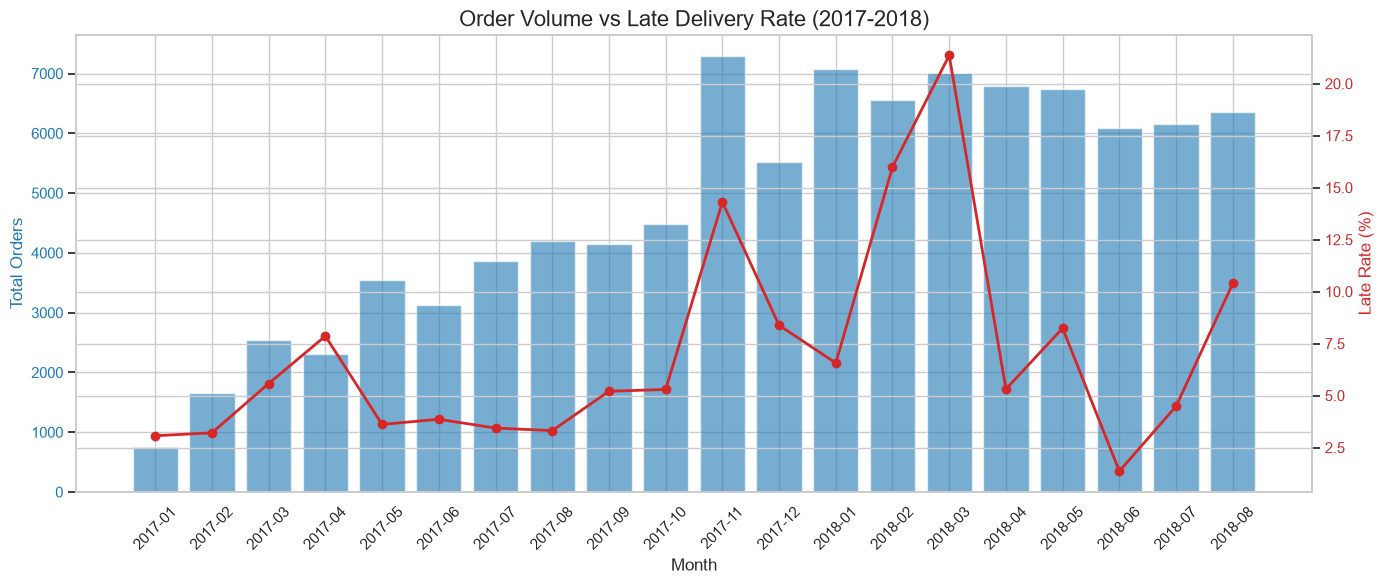

In [6]:
query_season = """
SELECT 
    year_ordered,
    month_ordered,
    COUNT(*) as total_orders,
    AVG(CAST(is_late AS DOUBLE)) * 100 as late_rate_pct
FROM orders_master
WHERE is_delivered = 1 AND year_ordered IN (2017, 2018)
GROUP BY year_ordered, month_ordered
ORDER BY year_ordered, month_ordered
"""
df_season = con.execute(query_season).df()
df_season['year_month'] = df_season['year_ordered'].astype(str) + '-' + df_season['month_ordered'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(14,6))

# Primary axis for Volume
color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Orders', color=color)
ax1.bar(df_season['year_month'], df_season['total_orders'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

# Secondary axis for Late Rate
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Late Rate (%)', color=color)  
ax2.plot(df_season['year_month'], df_season['late_rate_pct'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Order Volume vs Late Delivery Rate (2017-2018)')
fig.tight_layout()  
plt.show()

con.close()